In [1]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [2]:
model = MobileNetV2(weights="imagenet")

In [7]:
def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    decoded = decode_predictions(preds, top=3)[0]

    results = [(label, float(score)) for (_, label, score) in decoded]
    return results

In [9]:
test_image = "test_lion.jpg"   # <-- put your own animal image here
results = predict_animal(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step


In [10]:
print("Top Predictions:")
for label, score in results:
    print(f"{label}: {score*100:.2f}%")

Top Predictions:
lion: 73.52%
Arabian_camel: 3.08%
bison: 1.21%


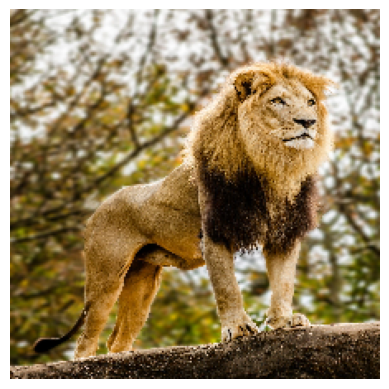

In [11]:
img = image.load_img(test_image, target_size=(224, 224))
plt.imshow(img)
plt.axis("off")
plt.show()